# Chapter 7 — Other Topics in RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §7

Regret minimization · Exploration-exploitation · Distributional RL · Intrinsic motivation ·
Hierarchical RL · Imitation learning · Offline RL

In [1]:
%pip install -q numpy matplotlib torch
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

## 7.1–7.2 Multi-Armed Bandits & Regret Minimization

Cumulative regret: $\text{Reg}(T)=T\mu^*-\sum_{t=1}^T r_t$

| Algorithm | Regret | Idea |
|-----------|--------|------|
| ε-greedy | $O(T^{2/3})$ | Explore with fixed prob |
| UCB1 | $O(\sqrt{T\log T})$ | Optimism under uncertainty |
| Thompson Sampling | $O(\sqrt{T\log T})$ | Bayesian posterior sampling |

Averaging over 100 runs…


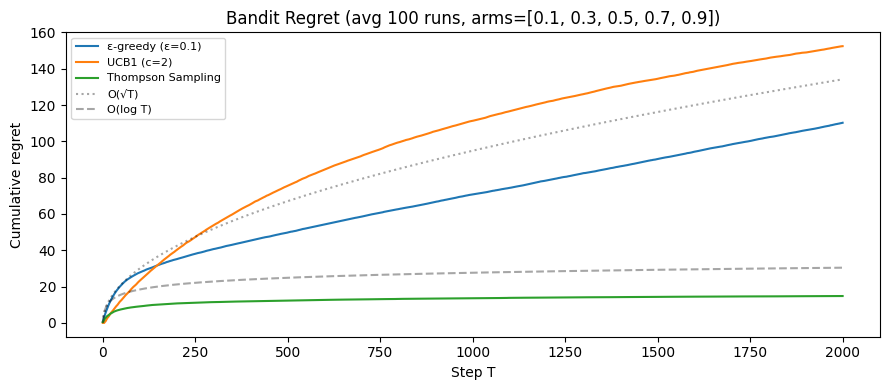

In [3]:
class BernoulliBandit:
    def __init__(self, means): self.means=np.array(means); self.opt=max(means)
    def pull(self, a): return float(np.random.rand()<self.means[a])

MEANS = [0.1, 0.3, 0.5, 0.7, 0.9]
T, N = 2000, 100

def eps_greedy_b(b, T, eps=0.1):
    est=np.zeros(len(b.means)); cnt=np.zeros(len(b.means)); reg=np.zeros(T)
    for t in range(T):
        a = np.random.randint(len(est)) if np.random.rand()<eps else est.argmax()
        r=b.pull(a); cnt[a]+=1; est[a]+=(r-est[a])/cnt[a]
        reg[t]=b.opt-b.means[a]
    return np.cumsum(reg)

def ucb1(b, T, c=2.0):
    est=np.zeros(len(b.means)); cnt=np.zeros(len(b.means)); reg=np.zeros(T)
    for a in range(len(b.means)): est[a]=b.pull(a); cnt[a]=1
    for t in range(len(b.means),T):
        a=(est+c*np.sqrt(np.log(t+1)/(cnt+1e-9))).argmax()
        r=b.pull(a); cnt[a]+=1; est[a]+=(r-est[a])/cnt[a]
        reg[t]=b.opt-b.means[a]
    return np.cumsum(reg)

def thompson(b, T):
    al=np.ones(len(b.means)); be=np.ones(len(b.means)); reg=np.zeros(T)
    for t in range(T):
        a=np.random.beta(al,be).argmax(); r=b.pull(a)
        al[a]+=r; be[a]+=(1-r)
        reg[t]=b.opt-b.means[a]
    return np.cumsum(reg)

avg = lambda fn: np.mean([fn(BernoulliBandit(MEANS),T) for _ in range(N)],axis=0)
print(f"Averaging over {N} runs…")
r_eps=avg(eps_greedy_b); r_ucb=avg(ucb1); r_ts=avg(thompson)

t=np.arange(1,T+1)
plt.figure(figsize=(9,4))
plt.plot(r_eps, label="ε-greedy (ε=0.1)")
plt.plot(r_ucb, label="UCB1 (c=2)")
plt.plot(r_ts,  label="Thompson Sampling")
plt.plot(t, 3*np.sqrt(t), "k:", alpha=0.35, label="O(√T)")
plt.plot(t, 4*np.log(t),  "k--",alpha=0.35, label="O(log T)")
plt.xlabel("Step T"); plt.ylabel("Cumulative regret")
plt.title(f"Bandit Regret (avg {N} runs, arms={MEANS})")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 7.3 Distributional RL

Model full return distribution $Z(s,a)$ instead of $\mathbb{E}[G]$.

**C51** (Bellemare et al., 2017): categorical over fixed atoms.

Captures risk, variance, multi-modality — useful for risk-sensitive control.

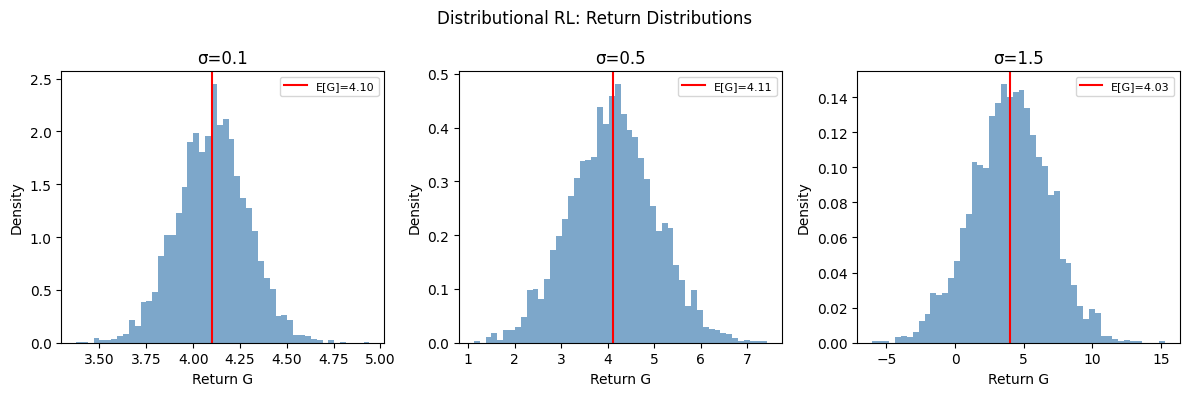

In [4]:
def sample_returns(depth=5, sigma=0.5, gamma=0.9, n=3000):
    return np.array([sum(gamma**t*np.random.normal(1,sigma) for t in range(depth))
                     for _ in range(n)])

fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax,sig in zip(axes,[0.1,0.5,1.5]):
    G=sample_returns(sigma=sig)
    ax.hist(G,bins=50,density=True,alpha=0.7,color="steelblue")
    ax.axvline(G.mean(),color="red",label=f"E[G]={G.mean():.2f}")
    ax.set_title(f"σ={sig}"); ax.legend(fontsize=8)
    ax.set_xlabel("Return G"); ax.set_ylabel("Density")
plt.suptitle("Distributional RL: Return Distributions")
plt.tight_layout(); plt.show()


## 7.6 Imitation Learning / Behavior Cloning

Learn from expert demos $(s,a^*)$ without reward:
$$\mathcal{L}_{\text{BC}}=-\mathbb{E}_{(s,a^*)\sim\mathcal{D}}[\log\pi_\theta(a^*\mid s)]$$

**Distribution shift**: errors at test time place agent in unseen states.

BC accuracy: 16/16 states match expert


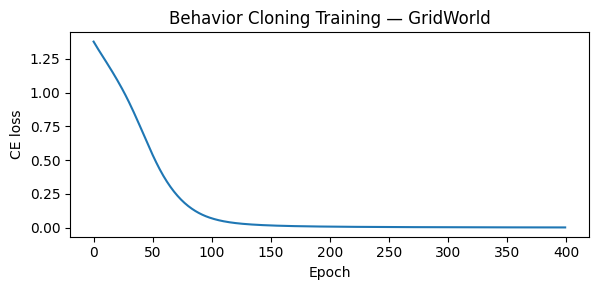

In [5]:
class GridWorld:
    SIZE=4; GOAL,HOLE=(3,3),(1,1)
    MOVES=[(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self): self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self._i(self.pos)
    def step(self,a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(3,r+dr)),max(0,min(3,c+dc)))
        if self.pos==self.GOAL: return self._i(self.pos), 1.0,True
        if self.pos==self.HOLE: return self._i(self.pos),-1.0,True
        return self._i(self.pos),-0.01,False
    def _i(self,p): return p[0]*4+p[1]

S, A = 16, 4

def expert(s):          # near-optimal: right first then down
    r,c = s//4, s%4
    return 3 if c<3 else 1

demos = [(s, expert(s)) for s in range(S) for _ in range(50)]
np.random.shuffle(demos)
sd = torch.tensor([d[0] for d in demos], dtype=torch.long)
ad = torch.tensor([d[1] for d in demos], dtype=torch.long)
sd_oh = torch.zeros(len(sd), S); sd_oh.scatter_(1, sd.unsqueeze(1), 1)

bc = nn.Sequential(nn.Linear(S,32), nn.ReLU(), nn.Linear(32,A))
opt = optim.Adam(bc.parameters(), lr=3e-3)
losses=[]
for _ in range(400):
    loss=nn.CrossEntropyLoss()(bc(sd_oh), ad)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

bc_pi = bc(torch.eye(S)).argmax(dim=1).numpy()
acc = sum(bc_pi[s]==expert(s) for s in range(S))
print(f"BC accuracy: {acc}/{S} states match expert")

plt.figure(figsize=(6,3))
plt.plot(losses); plt.xlabel("Epoch"); plt.ylabel("CE loss")
plt.title("Behavior Cloning Training — GridWorld"); plt.tight_layout(); plt.show()


## 7.7 Offline RL

Learn from fixed dataset $\mathcal{D}$ — no environment interaction.

Key challenge: policy may query actions **outside** $\mathcal{D}$ support.

**CQL** conservative Q-learning penalises OOD actions:
$$\min_Q\;\alpha\Bigl[\log\sum_a e^{Q(s,a)}-\mathbb{E}_{\beta}[Q]\Bigr]+\tfrac12\mathbb{E}_{\mathcal{D}}[(Q-\mathcal{B}^\pi Q)^2]$$

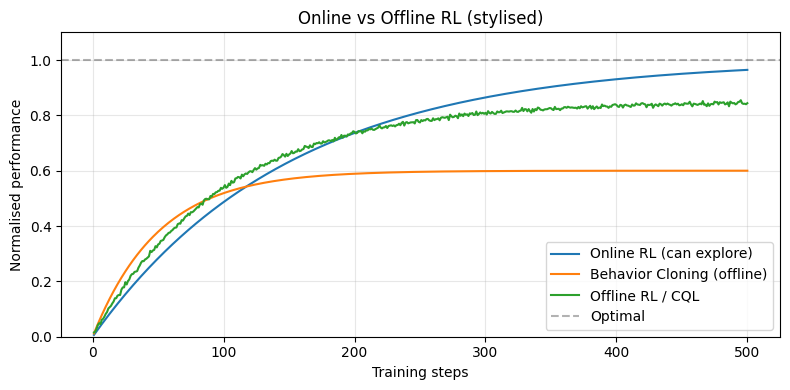

In [6]:
T_vals = np.arange(1,501); np.random.seed(0)
online  = 1.0 - np.exp(-T_vals/150)
bc_off  = 0.60*(1-np.exp(-T_vals/50))
cql_off = np.clip(0.85*(1-np.exp(-T_vals/100))+0.004*np.random.randn(500), 0, 1)

plt.figure(figsize=(8,4))
plt.plot(T_vals, online,  label="Online RL (can explore)")
plt.plot(T_vals, bc_off,  label="Behavior Cloning (offline)")
plt.plot(T_vals, cql_off, label="Offline RL / CQL")
plt.axhline(1.0, color="black", ls="--", alpha=0.3, label="Optimal")
plt.xlabel("Training steps"); plt.ylabel("Normalised performance")
plt.title("Online vs Offline RL (stylised)")
plt.legend(); plt.ylim(0,1.1); plt.grid(True,alpha=0.3); plt.tight_layout(); plt.show()


## 7.5 Hierarchical RL

Decompose long-horizon tasks into two levels:
- **High-level policy** $\pi^H$: selects sub-goals $g_t$ every $k$ steps
- **Low-level policy** $\pi^L$: reaches $g_t$ within $k$ steps

Motivation: sparse rewards over long horizons → credit assignment hard without hierarchy.

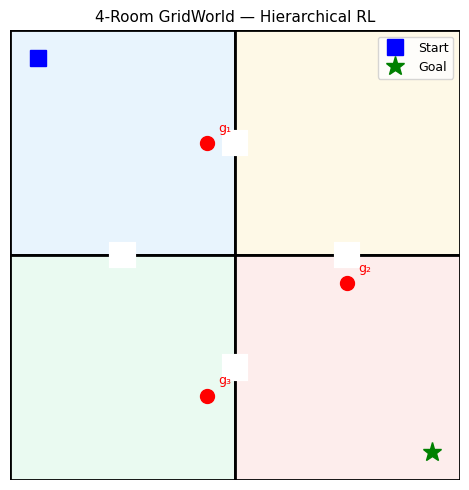

High-level: start → g₁ → g₂ → g₃ → goal  (4 sub-goals)
Low-level:  navigate within each room to reach sub-goal


In [7]:
# Illustrate hierarchical structure on 4-room GridWorld (conceptual)
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(0,8); ax.set_ylim(0,8); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("4-Room GridWorld — Hierarchical RL", fontsize=11)

import matplotlib.patches as patches

# Rooms
colors = ["#E8F4FD","#FEF9E7","#EAFAF1","#FDEDEC"]
for (rx,ry),col in zip([(0,4),(4,4),(0,0),(4,0)],colors):
    ax.add_patch(patches.Rectangle((rx,ry),4,4,fc=col,ec="black",lw=2))

# Doorways (narrow gaps)
for (x,y,w,h) in [(3.8,5.8,0.4,0.4),(5.8,3.8,0.4,0.4),(1.8,3.8,0.4,0.4),(3.8,1.8,0.4,0.4)]:
    ax.add_patch(patches.Rectangle((x,y),w,h,fc="white",ec="white",lw=3))

# Agent start, goal, sub-goals
ax.plot(0.5,7.5,"bs",ms=12,label="Start")
ax.plot(7.5,0.5,"g*",ms=14,label="Goal")
for (x,y),lbl in [((3.5,6),"g₁"),((6,3.5),"g₂"),((3.5,1.5),"g₃")]:
    ax.plot(x,y,"ro",ms=10); ax.text(x+0.2,y+0.2,lbl,fontsize=9,color="red")

ax.legend(loc="upper right",fontsize=9); plt.tight_layout(); plt.show()
print("High-level: start → g₁ → g₂ → g₃ → goal  (4 sub-goals)")
print("Low-level:  navigate within each room to reach sub-goal")
